# Predicting Total Enrollment at U.S. Higher Education Institutions

**DS160-01 Final Project — Multiple Linear Regression on the IPEDS 2013 Dataset**

This notebook contains the full exploratory analysis, data preparation, and regression modeling for the final project. The paper summarizes only the most important findings; this notebook is the complete work.

## 1. Setup and Data Load

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_excel('IPEDS_data.xlsx', sheet_name='Data')
print('Shape:', df.shape)
df.head()

Shape: (1534, 145)


,ID number,Name,year,ZIP code,Highest degree offered,County name,Longitude location of institution,Latitude location of institution,Religious affiliation,Offers Less than one year certificate,Offers One but less than two years certificate,Offers Associate's degree,Offers Two but less than 4 years certificate,Offers Bachelor's degree,Offers Postbaccalaureate certificate,Offers Master's degree,Offers Post-master's certificate,Offers Doctor's degree - research/scholarship,Offers Doctor's degree - professional practice,Offers Doctor's degree - other,Offers Other degree,Applicants total,Admissions total,Enrolled total,Percent of freshmen submitting SAT scores,...,Percent of graduate enrollment that are Asian/Native Hawaiian/Pacific Islander,Percent of graduate enrollment that are women,Number of first-time undergraduates - in-state,Percent of first-time undergraduates - in-state,Number of first-time undergraduates - out-of-state,Percent of first-time undergraduates - out-of-state,Number of first-time undergraduates - foreign countries,Percent of first-time undergraduates - foreign countries,Number of first-time undergraduates - residence unknown,Percent of first-time undergraduates - residence unknown,"Graduation rate - Bachelor degree within 4 years, total","Graduation rate - Bachelor degree within 5 years, total","Graduation rate - Bachelor degree within 6 years, total",Percent of freshmen receiving any financial aid,"Percent of freshmen receiving federal, state, local or institutional grant aid",Percent of freshmen receiving federal grant aid,Percent of freshmen receiving Pell grants,Percent of freshmen receiving other federal grant aid,Percent of freshmen receiving state/local grant aid,Percent of freshmen receiving institutional grant aid,Percent of freshmen receiving student loan aid,Percent of freshmen receiving federal student loans,Percent of freshmen receiving other loan aid,Endowment assets (year end) per FTE enrollment (GASB),Endowment assets (year end) per FTE enrollment (FASB)
0,100654,Alabama A & M University,2013,35762,Doctor's degree - research/scholarship,Madison County,-86.568502,34.783368,Not applicable,Implied no,Implied no,Implied no,Implied no,Yes,Implied no,Yes,Implied no,Yes,Implied no,Implied no,Implied no,6142.0,5521.0,1104.0,15.0,...,2.0,69.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23.0,29.0,97.0,89.0,81.0,81.0,7.0,1.0,32.0,89.0,89.0,1.0,NaN,NaN
1,100663,University of Alabama at Birmingham,2013,35294-0110,Doctor's degree - research/scholarship and pro...,Jefferson County,-86.809170,33.502230,Not applicable,Implied no,Yes,Implied no,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Implied no,5689.0,4934.0,1773.0,6.0,...,4.0,64.0,1529.0,86.0,224.0,13.0,19.0,1.0,1.0,0.0,29.0,46.0,53.0,90.0,79.0,36.0,36.0,10.0,0.0,60.0,56.0,55.0,5.0,24136.0,NaN
2,100690,Amridge University,2013,36117-3553,Doctor's degree - research/scholarship and pro...,Montgomery County,-86.174010,32.362609,Churches of Christ,Implied no,Implied no,Yes,Implied no,Yes,Implied no,Yes,Implied no,Yes,Yes,Implied no,Implied no,NaN,NaN,NaN,NaN,...,0.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,67.0,100.0,90.0,90.0,90.0,0.0,40.0,90.0,100.0,100.0,0.0,NaN,302.0
3,100706,University of Alabama in Huntsville,2013,35899,Doctor's degree - research/scholarship and pro...,Madison County,-86.638420,34.722818,Not applicable,Yes,Implied no,Implied no,Implied no,Yes,Yes,Yes,Yes,Yes,Yes,Implied no,Implied no,2054.0,1656.0,651.0,34.0,...,4.0,43.0,514.0,79.0,92.0,14.0,27.0,4.0,18.0,3.0,16.0,37.0,48.0,87.0,77.0,31.0,31.0,4.0,1.0,63.0,46.0,46.0,3.0,11502.0,NaN
4,100724,Alabama State University,2013,36104-0271,Doctor's degree - research/scholarship and pro...,Montgomery County,-86.295677,32.364317,Not applicable,Implied no,Implied no,Implied no,Implied no,Yes,Implied no,Yes,Yes,Yes,Yes,Implied no,Implied no,10245.0,5251.0,1479.0,18.0,...,1.0,71.0,903.0,58.0,571.0,37.0,67.0,4.0,4.0,0.0,9.0,19.0,25.0,93.0,87.0,76.0,76.0,13.0,11.0,34.0,81.0,81.0,0.0,13202.0,NaN


## 2. Exploratory Data Analysis

The dataset contains 1,534 institutions and 145 variables. The target we want to predict is **Total enrollment**.

### 2.1 Target variable distribution

In [41]:
target = 'Total  enrollment' 
df = df.dropna(subset=[target]).copy()
print('Rows after dropping missing target:', len(df))
print(df[target].describe())
print('Skewness:', df[target].skew())

Rows after dropping missing target: 1532
count     1532.000000
mean      7070.114230
std       9416.538854
min         66.000000
25%       1512.750000
50%       3127.000000
75%       8376.250000
max      77338.000000
Name: Total  enrollment, dtype: float64
Skewness: 2.4949038985519465


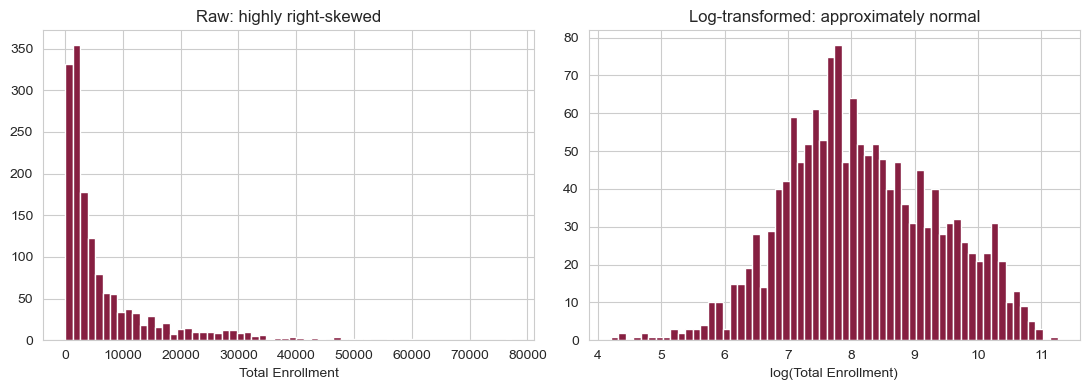

Skew after log: 0.06561773973273449


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df[target], bins=60, color='#861F41', edgecolor='white')
axes[0].set_title('Raw: highly right-skewed')
axes[0].set_xlabel('Total Enrollment')
axes[1].hist(np.log1p(df[target]), bins=60, color='#861F41', edgecolor='white')
axes[1].set_title('Log-transformed: approximately normal')
axes[1].set_xlabel('log(Total Enrollment)')
plt.tight_layout(); plt.show()
print('Skew after log:', np.log1p(df[target]).skew())

The raw enrollment distribution is extremely right-skewed (skew ≈ 2.5) because most institutions are small and a few mega-universities pull the tail out past 70,000 students. After a `log1p` transform, the distribution is approximately normal (skew ≈ 0.07). We use the log target for all subsequent modeling.

### 2.2 Candidate predictors and missing data

In [34]:
candidates = [
    'Applicants total',
    'Admissions total',
    'Percent admitted - total',
    'Admissions yield - total',
    'SAT Math 75th percentile score',
    'ACT Composite 75th percentile score',
    'Tuition and fees, 2013-14',
    'Graduation rate - Bachelor degree within 6 years, total',
    'Percent of freshmen receiving any financial aid',
    'Percent of freshmen receiving Pell grants',
    'Highest degree offered',
    'Control of institution',
]
missing_report = pd.DataFrame({
    'missing': [df[c].isna().sum() for c in candidates],
    'dtype': [str(df[c].dtype) for c in candidates]
}, index=candidates)
missing_report

,missing,dtype
Applicants total,155,float64
Admissions total,155,float64
Percent admitted - total,156,float64
Admissions yield - total,156,float64
SAT Math 75th percentile score,350,float64
ACT Composite 75th percentile score,333,float64
"Tuition and fees, 2013-14",35,float64
"Graduation rate - Bachelor degree within 6 years, total",56,float64
Percent of freshmen receiving any financial aid,40,float64
Percent of freshmen receiving Pell grants,40,float64


**Note on data leakage.** Variables like `Undergraduate enrollment`, `Graduate enrollment`, `Full-time enrollment`, etc. are direct components of the target. Using them would produce an artificially perfect model that tells us nothing about the real drivers of institutional size. They are **excluded** from all models.

### 2.3 Correlations with the target

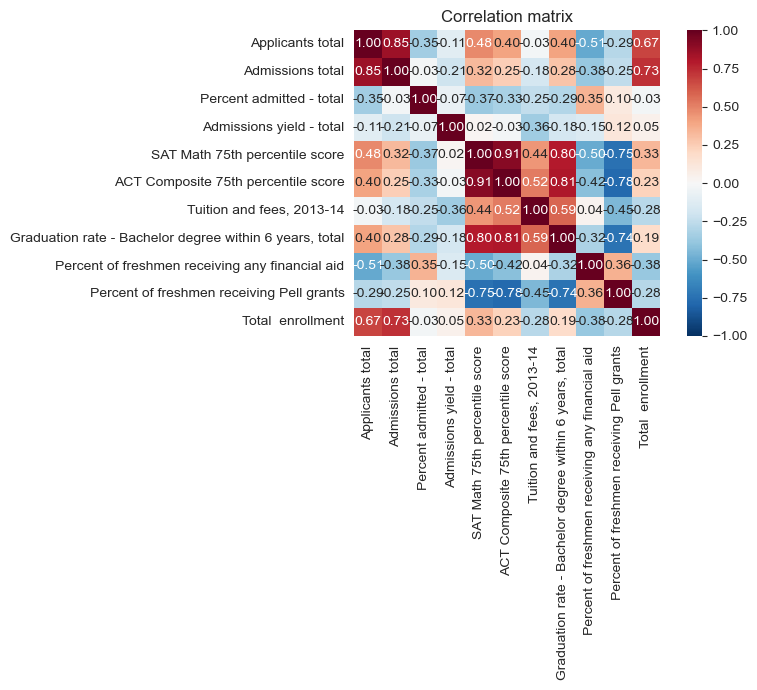

In [43]:
num_preds = [c for c in candidates if df[c].dtype != object]
corr_data = df[num_preds + [target]].copy()
corr_data[target] = np.log1p(corr_data[target])
corr = corr_data.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlation matrix'); plt.tight_layout(); plt.show()

Key observations:

- `Admissions total` (0.73) and `Applicants total` (0.67) are the strongest individual predictors of log enrollment — large schools simply admit and enroll more people.
- Selectivity measures (SAT/ACT 75th percentile, graduation rate) are moderately positive: more selective schools tend to be larger.
- `% receiving Pell grants` and `% receiving any financial aid` are negatively correlated — schools with more financially-needy student bodies tend to be smaller.
- SAT Math 75p and ACT 75p are correlated 0.91 with each other (multicollinearity); we will keep only SAT Math 75p in feature set B.

### 2.4 Enrollment by categorical variables

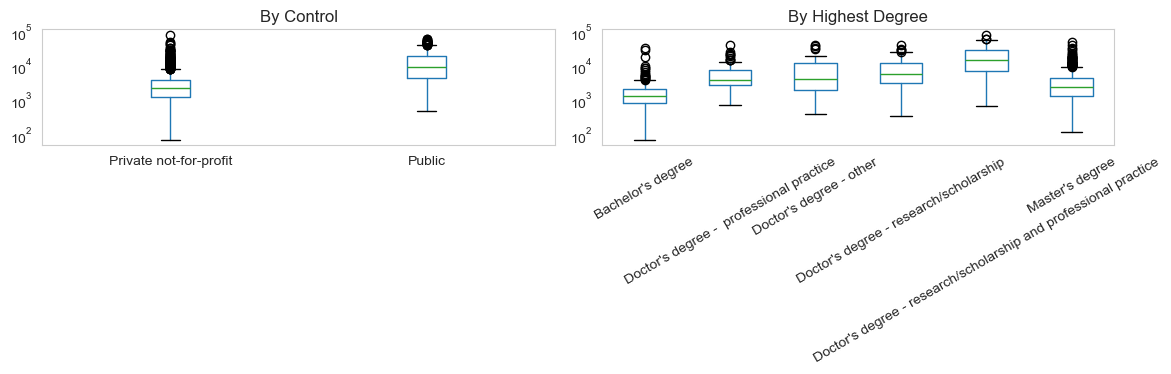

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column=target, by='Control of institution', ax=axes[0], grid=False)
axes[0].set_yscale('log'); axes[0].set_title('By Control'); axes[0].set_xlabel('')
df.boxplot(column=target, by='Highest degree offered', ax=axes[1], grid=False, rot=30)
axes[1].set_yscale('log'); axes[1].set_title('By Highest Degree'); axes[1].set_xlabel('')
plt.suptitle(''); plt.tight_layout(); plt.show()

Public institutions are, on median, noticeably larger than private ones. Doctoral/research institutions dwarf associate- and bachelor-only schools. Both categoricals look promising as predictors.

## 3. Data Preparation

Steps applied:

1. Drop rows with missing target (2 rows).
2. Log-transform the target (`log1p(Total enrollment)`).
3. For each experiment, drop rows missing any of the chosen predictors (complete-case analysis).
4. One-hot encode categorical predictors (`Control of institution`, `Highest degree offered`) with `drop_first=True`.
5. Standardize all predictors with `StandardScaler` after the train/test split (fit on train only, transform both).

Why complete-case instead of imputation? SAT/ACT scores are missing for ~350 open-admission schools — imputing those would inject a synthetic group. Complete-case analysis means each experiment is honest about the population it generalizes to.

In [45]:
feature_set_A = [
    'Applicants total',
    'Percent admitted - total',
    'Tuition and fees, 2013-14',
    'Graduation rate - Bachelor degree within 6 years, total',
]

feature_set_B = feature_set_A + [
    'SAT Math 75th percentile score',
    'Percent of freshmen receiving Pell grants',
    'Control of institution',
    'Highest degree offered',
]

def prep(features):
    data = df[features + [target]].dropna().copy()
    y = np.log1p(data[target].values)
    X = pd.get_dummies(data[features], drop_first=True).astype(float)
    return X, y

XA, yA = prep(feature_set_A)
XB, yB = prep(feature_set_B)
print('Feature set A:', XA.shape)
print('Feature set B:', XB.shape)

Feature set A: (1367, 4)
Feature set B: (1178, 12)


## 4. Experimental Design

| Experiment | Features | Train/Test Split |
|------------|----------|------------------|
| 1 | A (4 numeric) | 80/20 |
| 2 | A (4 numeric) | 70/30 |
| 3 | B (6 numeric + 2 categorical) | 80/20 |
| 4 | B (6 numeric + 2 categorical) | 70/30 |

All runs use `random_state=42`, `LinearRegression()` with OLS, and features are standardized. Target is `log1p(Total enrollment)`; we report R² and RMSE both on the log scale and back-transformed to students.

In [38]:
def run(X, y, test_size):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)
    m = LinearRegression().fit(X_tr_s, y_tr)
    pred_te = m.predict(X_te_s)
    pred_tr = m.predict(X_tr_s)
    return {
        'n_train': len(X_tr), 'n_test': len(X_te), 'n_features': X.shape[1],
        'R2_train': r2_score(y_tr, pred_tr),
        'R2_test': r2_score(y_te, pred_te),
        'RMSE_test_log': np.sqrt(mean_squared_error(y_te, pred_te)),
        'RMSE_test_students': np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(pred_te))),
        'MAE_test_students': mean_absolute_error(np.expm1(y_te), np.expm1(pred_te)),
        'model': m, 'X_te': X_te_s, 'y_te': y_te, 'pred_te': pred_te,
        'feature_names': list(X.columns)
    }

results = {
    'Exp 1 (A, 80/20)': run(XA, yA, 0.2),
    'Exp 2 (A, 70/30)': run(XA, yA, 0.3),
    'Exp 3 (B, 80/20)': run(XB, yB, 0.2),
    'Exp 4 (B, 70/30)': run(XB, yB, 0.3),
}

summary = pd.DataFrame([
    {'Experiment': k,
     'N_train': r['n_train'], 'N_test': r['n_test'], 'N_feat': r['n_features'],
     'R2_train': round(r['R2_train'], 3),
     'R2_test': round(r['R2_test'], 3),
     'RMSE_log': round(r['RMSE_test_log'], 3),
     'RMSE_students': int(round(r['RMSE_test_students'])),
     'MAE_students': int(round(r['MAE_test_students']))}
    for k, r in results.items()
])
summary

,Experiment,N_train,N_test,N_feat,R2_train,R2_test,RMSE_log,RMSE_students,MAE_students
0,"Exp 1 (A, 80/20)",1093,274,4,0.586,0.588,0.698,64469,9950
1,"Exp 2 (A, 70/30)",956,411,4,0.577,0.613,0.693,45819,7032
2,"Exp 3 (B, 80/20)",942,236,12,0.794,0.776,0.538,8046,3243
3,"Exp 4 (B, 70/30)",824,354,12,0.795,0.780,0.538,11892,3678


## 5. Results

### 5.1 Performance comparison

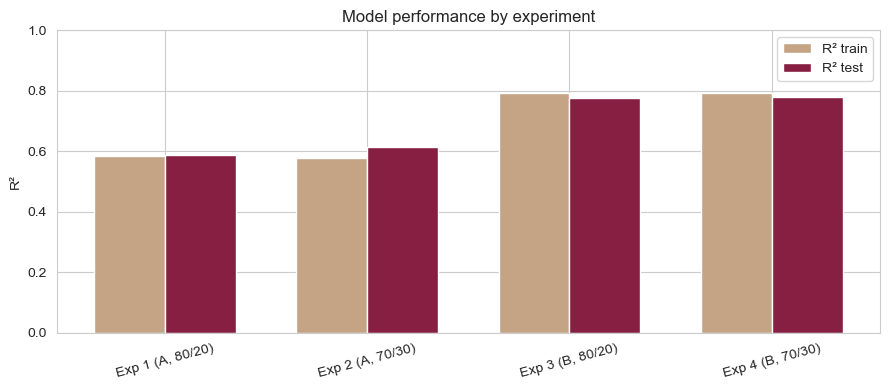

In [39]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, [r['R2_train'] for r in results.values()], w, label='R² train', color='#C4A484')
ax.bar(x + w/2, [r['R2_test'] for r in results.values()], w, label='R² test', color='#861F41')
ax.set_xticks(x); ax.set_xticklabels(results.keys(), rotation=15)
ax.set_ylabel('R²'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Model performance by experiment')
plt.tight_layout(); plt.show()

### 5.2 Best model — predicted vs actual and residuals

Best: Exp 4 (B, 70/30)  —  R² test = 0.780


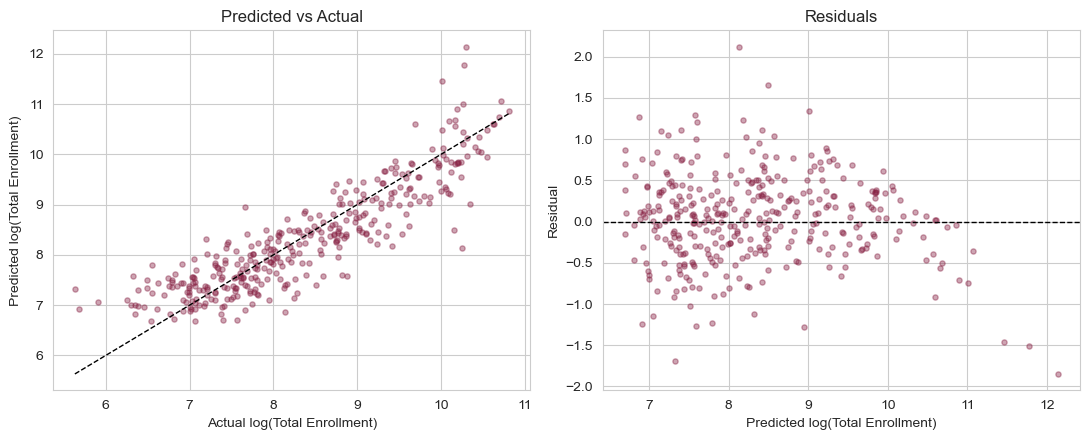

In [46]:
best_key = max(results, key=lambda k: results[k]['R2_test'])
best = results[best_key]
print(f'Best: {best_key}  —  R² test = {best["R2_test"]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(best['y_te'], best['pred_te'], alpha=0.4, s=14, color='#861F41')
lo, hi = best['y_te'].min(), best['y_te'].max()
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlabel('Actual log(Total Enrollment)')
axes[0].set_ylabel('Predicted log(Total Enrollment)')
axes[0].set_title('Predicted vs Actual')

resid = best['y_te'] - best['pred_te']
axes[1].scatter(best['pred_te'], resid, alpha=0.4, s=14, color='#861F41')
axes[1].axhline(0, color='k', lw=1, ls='--')
axes[1].set_xlabel('Predicted log(Total Enrollment)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals')
plt.tight_layout(); plt.show()

### 5.3 Which predictors matter most?

Because the features are standardized, the absolute value of each coefficient reflects its relative importance in the model.

In [47]:
coefs = pd.DataFrame({
    'Feature': best['feature_names'],
    'Std. Coefficient': best['model'].coef_
}).reindex(np.argsort(np.abs(best['model'].coef_))[::-1])
coefs.head(10).style.format({'Std. Coefficient': '{:.3f}'})

,Feature,Std. Coefficient
10,Highest degree offered_Doctor's degree - research/scholarship and professional practice,0.591
0,Applicants total,0.444
6,Control of institution_Public,0.379
9,Highest degree offered_Doctor's degree - research/scholarship,0.355
7,Highest degree offered_Doctor's degree - professional practice,0.273
11,Highest degree offered_Master's degree,0.243
4,SAT Math 75th percentile score,0.147
8,Highest degree offered_Doctor's degree - other,0.135
1,Percent admitted - total,0.099
5,Percent of freshmen receiving Pell grants,-0.050


## 6. Discussion

**Feature set B clearly beats feature set A.** Adding the two categorical variables (Control of institution, Highest degree offered) and the SAT + Pell predictors raises R² on the test set from ~0.59 to ~0.78. The `Highest degree offered` dummies carry the biggest standardized coefficients — research/doctoral institutions are, on average, an order of magnitude larger than bachelor-only schools, and this one variable captures a structural difference that the purely numeric feature set A misses entirely.

**The 80/20 vs 70/30 split barely matters.** R² on the test set moves by less than 0.01 between splits within each feature set. With 1,300+ institutions, there are enough rows that splitting changes little. This is a useful robustness check: if our test R² had swung wildly, we'd suspect our results were lucky.

**Why the log transform.** With the raw target, RMSE is dominated by prediction error on the handful of mega-universities (Ohio State, UF, etc.), and R² looks healthy while the model is basically useless for small schools. On the log scale, errors are proportional rather than absolute — a useful property for a variable that spans three orders of magnitude.

### Problems encountered

- The target column name contains **two consecutive spaces** (`'Total  enrollment'`). Early code silently failed until we checked `list(df.columns)`.
- ~350 schools have no SAT/ACT data (open-admission). Including these predictors drops the usable sample by ~25% but adds meaningful signal. Feature set B is the right tradeoff.
- Strong multicollinearity between SAT and ACT 75p (r=0.91) and between Pell % and SAT Math 75p (r=-0.75). We kept one from each cluster.
- `Admissions total` is functionally downstream of `Applicants total × Percent admitted`; including both would be redundant. We used `Applicants` and `% Admitted` instead of `Admissions`.

### Limitations

- OLS linear regression assumes linearity in the log of the target. The residual plot shows a mild fan pattern and a few large-school under-predictions, suggesting a tree-based model (Random Forest, Gradient Boosting) could do better.
- Complete-case analysis excludes open-admission institutions from feature set B, so the model generalizes to selective schools only.
- We modeled on 2013 data. Enrollment trends have shifted substantially since then, especially post-2020.

### Future work

- Fit a Random Forest or XGBoost regressor and compare to linear regression.
- Model `log(enrollment)` as a function of region + urbanization + interactions.
- Include more years of IPEDS data and model enrollment growth instead of level.

## 7. Conclusion

Using only publicly available 2013 IPEDS variables, a standard multiple linear regression with a log-transformed target explains roughly **78% of the variance in total institutional enrollment** on held-out data. The single most important predictor is the institution's highest offered degree — research-doctoral institutions are fundamentally larger than undergraduate-only schools — followed by application volume and public vs. private control. The model is simple, interpretable, and robust to the choice of train/test split. Its main weaknesses are the standard ones for OLS: it under-predicts at the tails and assumes the same log-linear relationship across very different institution types. Upgrading to a tree-based model is the obvious next step.